# ERA5 Pretrained - flash-aurora Engine

Same data and forecast setup as the upstream [Microsoft Aurora example](microsoft-aurora/docs/example_era5.ipynb) (2023-01-01, 2-step rollout → 12:00 / 18:00 UTC), but uses the **flash-aurora Engine** `DataDownloader` for ERA5 fetch and inference.

> **Asset root:** default is `./assets` under the working directory. Here we use the data disk in developing environment, comment `ASSET_ROOT = Path("/root/autodl-tmp/aurora")` in the setup cell to use your own disk.

## Prerequisites

1. **CDS credentials** (any one): environment variable `CDSAPI_KEY`, `~/.cdsapirc`, or interactive `getpass` in the notebook below.
2. **Download dependencies**: `pip install cdsapi netcdf4` (or `uv pip install cdsapi netcdf4`).
3. **Checkpoint / data root:** defaults to `./assets`. Uncomment `ASSET_ROOT` in the setup cell to point at an absolute data-disk path.
4. **GPU** You need a GPU for 0.25° global inference.
5. **Network**: CDS uses the official Copernicus API only; for Hugging Face, set `USE_HF_MIRROR = True` in the setup cell when `huggingface.co` is unreachable.


In [1]:
from datetime import datetime
from pathlib import Path

from flash_aurora.engine import (
    DEFAULT_PRESETS,
    DataDownloader,
    HF_MIRROR_ENDPOINT,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "era5_pretrained"
DAY = "2023-01-01"
VALID_TIME = datetime(2023, 1, 1, 6)
TIME_INDEX = 1
ROLLOUT_STEPS = 2

# Named tier or combo: backbone@encoder_decoder (see README).
INFERENCE_PRECISION = "bf16_mixed@fp32"  # e.g. "tf32@tf32", "fp32", "bf16@fp32"

# Default: ./assets under the notebook working directory (created if missing).
ASSET_ROOT: Path | str | None = None

# Optional — absolute path to a mounted data disk with checkpoints/cache (uncomment to use):
ASSET_ROOT = Path("/root/autodl-tmp/aurora")

if ASSET_ROOT is not None:
    root = Path(ASSET_ROOT).expanduser()
    if not root.is_absolute():
        raise ValueError("ASSET_ROOT must be an absolute path")
    ASSET_ROOT = root.resolve()
else:
    ASSET_ROOT = (Path.cwd() / "assets").resolve()
    ASSET_ROOT.mkdir(parents=True, exist_ok=True)

variant = DEFAULT_PRESETS.get(PRESET).variant
CHECKPOINT_PATH = ASSET_ROOT / variant.checkpoint_filename
USE_HF_MIRROR = False  # True -> https://hf-mirror.com

if CHECKPOINT_PATH.is_file():
    # Local checkpoint on disk: load weights from ASSET_ROOT, skip Hub download.
    CHECKPOINT_ARG = CHECKPOINT_PATH
    ALLOW_HUB_DOWNLOAD = False
    HF_ENDPOINT = None
    print("checkpoint: local", safe_path(CHECKPOINT_PATH))
else:
    # No local checkpoint: engine.load() will fetch from Hugging Face into ASSET_ROOT.
    CHECKPOINT_ARG = None
    ALLOW_HUB_DOWNLOAD = True
    HF_ENDPOINT = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint: missing locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  filename:", variant.checkpoint_filename)
    print("  hf_endpoint:", HF_ENDPOINT or "https://huggingface.co (default)")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
cache_dir = downloader.resolve_cache_dir()

print("cache_dir:", safe_path(cache_dir))
print("asset_root:", safe_path(ASSET_ROOT))
print("allow_hub_download:", ALLOW_HUB_DOWNLOAD)


checkpoint: local ~/autodl-tmp/aurora/aurora-0.25-pretrained.ckpt
cache_dir: ~/autodl-tmp/aurora/era5
asset_root: ~/autodl-tmp/aurora
allow_hub_download: False


## 1. Download ERA5 (CDS API)

Downloads three NetCDF files under ``<ASSET_ROOT>/era5/``. If they are already present, the next cell skips CDS and does not use your API quota.


In [2]:
import getpass
import os
from pathlib import Path

from flash_aurora.engine import DownloadResult
from flash_aurora.engine.core.redaction import safe_path

era5_paths = downloader.expected_paths(VALID_TIME)
missing = downloader.missing(VALID_TIME)

if missing: # toggle downloader
    # CDS credentials only when a download is actually needed.
    # 1) Environment: export CDSAPI_KEY=your-key
    # 2) Inline assignment for local testing only — do not commit keys to git
    # 3) Interactive getpass — paste into the hidden input when prompted
    CDS_API_KEY = os.environ.get("CDSAPI_KEY", "").strip() or None
    # CDS_API_KEY = "paste-your-cds-key-here"
    if CDS_API_KEY is None and not Path.home().joinpath(".cdsapirc").is_file():
        CDS_API_KEY = getpass.getpass("CDS API key: ").strip() or None

    if not CDS_API_KEY and not Path.home().joinpath(".cdsapirc").is_file():
        raise ValueError(
            "No CDS credentials found. Set CDSAPI_KEY, create ~/.cdsapirc, "
            "or paste your key when prompted by getpass."
        )

    # If cds.climate.copernicus.eu is slow or blocked, set an HTTP proxy (cdsapi uses requests):
    # os.environ["HTTPS_PROXY"] = "http://127.0.0.1:7890"

    print("Missing ERA5 files:", missing)
    result = downloader.ensure(VALID_TIME, cds_api_key=CDS_API_KEY)
else:
    print("ERA5 cache already complete under", safe_path(cache_dir))
    result = DownloadResult(
        cache_dir=cache_dir,
        paths=era5_paths,
        downloaded=(),
        skipped=tuple(era5_paths),
    )

print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")


ERA5 cache already complete under ~/autodl-tmp/aurora/era5
downloaded: ()
skipped: ('static', 'surface', 'atmospheric')
  static: ~/autodl-tmp/aurora/era5/static.nc
  surface: ~/autodl-tmp/aurora/era5/2023-01-01-surface-level.nc
  atmospheric: ~/autodl-tmp/aurora/era5/2023-01-01-atmospheric.nc


## 2. Build the initial condition with the Engine

Equivalent to manually assembling a `Batch` in the upstream notebook; handled by `CdsEra5Adapter` and `BatchValidator`.


In [3]:
from flash_aurora.engine import AuroraEngine, InitialConditionBuilder

engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=CHECKPOINT_ARG,
    allow_hub_download=ALLOW_HUB_DOWNLOAD,
    hf_mirror=USE_HF_MIRROR,
    hf_endpoint=None if USE_HF_MIRROR else HF_ENDPOINT,
)

request = downloader.ingest_request(VALID_TIME, time_index=TIME_INDEX, download=False)

builder = InitialConditionBuilder(engine.config)
batch = builder.from_source(request)
print("IC time:", batch.metadata.time)
print("spatial:", batch.spatial_shape)


IC time: (datetime.datetime(2023, 1, 1, 6, 0),)
spatial: torch.Size([721, 1440])


## 3. Load the model and rollout

Set `INFERENCE_PRECISION` in the setup cell using the `backbone@encoder_decoder` form (for example `bf16_mixed@fp32`). Assign it to `engine.config.inference_precision` **before** `load()` so Triton fusion, CuTe window attention, and matmul modes are wired consistently. Then run the 2-step rollout as in the upstream notebook.


In [4]:
import torch

from flash_aurora.aurora.model.inference_precision import describe_inference_config

# Must be set before load() — see README "Inference precision tiers".
engine.config.inference_precision = INFERENCE_PRECISION

engine.load()
print("device:", next(engine.model.parameters()).device)

cfg = engine.model.inference_config
if cfg is not None:
    print("inference tier:", cfg.config_label)
    print(describe_inference_config(cfg))

with torch.inference_mode():
    preds = engine.run_from_adapter(request, steps=ROLLOUT_STEPS)

preds = [pred.to("cpu") for pred in preds]
print("predictions:", [str(p.metadata.time[0]) for p in preds])


device: cuda:0
inference tier: bf16_mixed@fp32
backbone matmul hybrid: BF16 attention QKV/proj + BF16 MLP; TF32 elsewhere; encoder/decoder matmul FP32 (native Perceiver SDPA); Triton layout+AdaLN; CuTe window attention (bfloat16); backbone activations float32
predictions: ['2023-01-01 12:00:00', '2023-01-01 18:00:00']


## 4. Visualize: Aurora prediction vs ERA5 Ground Truth

Left column: model forecast. Right column: ERA5 2 m temperature at the matching valid time (K to °C).


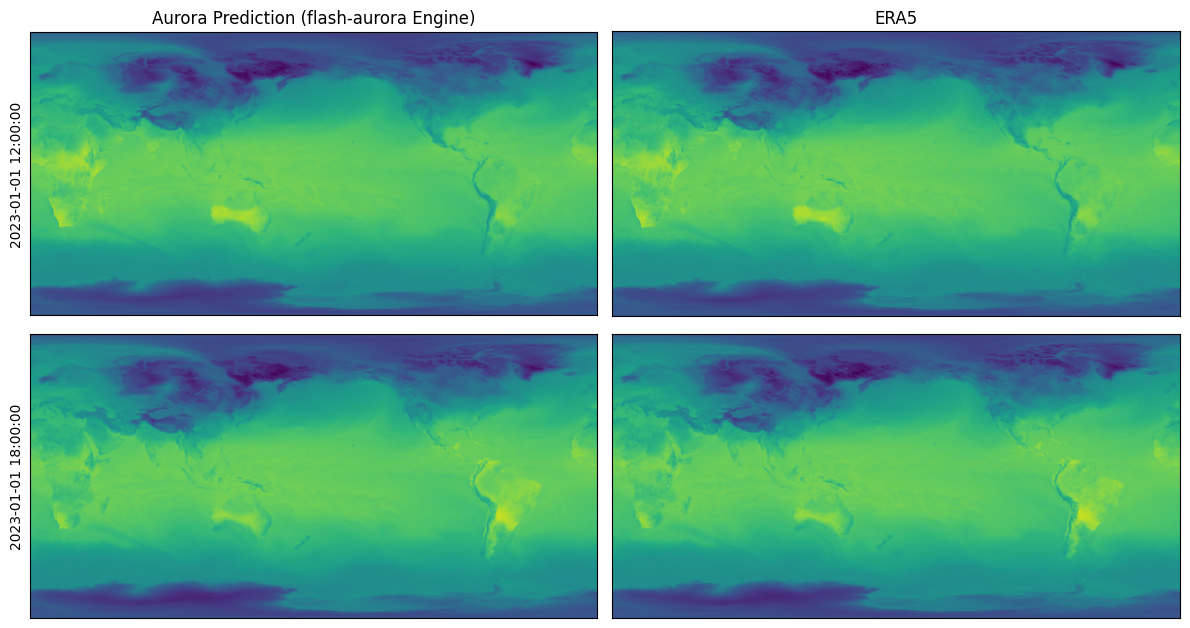

In [5]:
import matplotlib.pyplot as plt
import xarray as xr

surface_path = result.paths["surface"]
surf_vars_ds = xr.open_dataset(surface_path, engine="netcdf4")

fig, ax = plt.subplots(2, 2, figsize=(12, 6.5))

for i in range(ax.shape[0]):
    pred = preds[i]

    ax[i, 0].imshow(pred.surf_vars["2t"][0, 0].numpy() - 273.15, vmin=-50, vmax=50)
    ax[i, 0].set_ylabel(str(pred.metadata.time[0]))
    if i == 0:
        ax[i, 0].set_title("Aurora Prediction (flash-aurora Engine)")
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])

    ax[i, 1].imshow(surf_vars_ds["t2m"][2 + i].values - 273.15, vmin=-50, vmax=50)
    if i == 0:
        ax[i, 1].set_title("ERA5")
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])

plt.tight_layout()
plt.show()


## 5. (Optional) Export rollout to NetCDF
`rollout_and_export` runs the rollout again from the same initial `batch`, then writes one file per step under `EXPORT_DIR` (`prediction-000.nc`, `prediction-001.nc`, …). It does **not** reuse the `preds` from section 3.
The first rollout in section 3 is often slower (checkpoint load, CuTe/Triton JIT). This cell is usually faster on a warm GPU because kernels are already compiled; most of the time here is still inference, not disk I/O.
Skip this section if you only need in-memory predictions.

In [6]:
# Model already initialized and moved to GPU above
EXPORT_DIR = ASSET_ROOT / "output" / "era5_pretrained"
paths = list(engine.rollout_and_export(batch, steps=ROLLOUT_STEPS, export_dir=EXPORT_DIR))
for p in paths:
    print(safe_path(p), p.is_file())

~/autodl-tmp/aurora/output/era5_pretrained/prediction-000.nc True
~/autodl-tmp/aurora/output/era5_pretrained/prediction-001.nc True
